# Bilibili (BILI) Financial Statement Analysis Notebook

This notebook retrieves financial statements for Bilibili Inc. (BILI) using `yfinance`, constructs a trailing twelve months (TTM) view from quarterly data, calculates selected financial ratios, creates charts, and exports analytical tables for report writing.

## Objectives
1. Retrieve annual and quarterly financial statements
2. Construct TTM financial data
3. Standardize key line items across statements
4. Calculate selected ratios for profitability, liquidity, solvency, efficiency, growth, and cash flow quality
5. Visualize key financial trends
6. Export clean tables for report use

## Important note
Bilibili is a foreign private issuer. In formal report writing, its latest annual filing is generally **Form 20-F**, not Form 10-K.

## Unit convention
All statement values and amount-based output tables in this notebook are displayed **in thousands**.
Ratio tables are not scaled.

In [6]:
# Install packages if needed
# Uncomment the next line if your environment does not have these packages
# !pip install yfinance openpyxl matplotlib pandas numpy

## 1. Import libraries and define the ticker

In [7]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.patches import FancyBboxPatch

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

ticker_symbol = "BILI"
output_dir = Path("./bili_output")
output_dir.mkdir(exist_ok=True)

print(f"Output folder: {output_dir.resolve()}")

Output folder: /Users/fredericzhang/Documents/Study/ACCT/ACCT_626/bili_output


## 2. Define helper functions first

These functions are defined early so that later cells can call them without ordering errors.

In [8]:
def pick_value(df, candidates):
    """
    Return the first matching row from df among candidate row names.
    If no row is found, return an empty numeric series aligned to df columns.
    """
    for name in candidates:
        if name in df.index:
            return df.loc[name]
    return pd.Series(index=df.columns, dtype="float64")

def avg_series(series_):
    """
    Compute the simple average of current and next period values.
    Since columns are ordered from newest to oldest,
    the average for a given column is based on that column and the next older column.
    """
    s = series_.copy()
    out = pd.Series(index=s.index, dtype="float64")
    cols = list(s.index)
    for i, col in enumerate(cols):
        if i < len(cols) - 1:
            out[col] = (s.iloc[i] + s.iloc[i + 1]) / 2
        else:
            out[col] = np.nan
    return out

def safe_div(numerator, denominator):
    """
    Divide safely and replace zero denominators with NaN.
    """
    if isinstance(denominator, pd.Series):
        denominator = denominator.replace({0: np.nan})
    return numerator / denominator

def scale_df(df, divisor=1000):
    """
    Scale a dataframe by a divisor for display/export purposes.
    In this notebook, amount-based tables are displayed in thousands.
    """
    return df / divisor

def clean_columns(df):
    """
    Convert datetime-like columns to short string labels.
    Keep 'TTM' unchanged.
    """
    df = df.copy()
    new_cols = []
    for c in df.columns:
        if c == "TTM":
            new_cols.append("TTM")
        else:
            new_cols.append(str(c)[:10])
    df.columns = new_cols
    return df

def build_ttm_flow(df, min_quarters=1):
    """
    Build TTM for flow statements (income statement / cash flow).
    If 4 quarters are available, sum the latest 4 quarters.
    If fewer quarters are available but at least min_quarters exist, sum all available quarters.
    """
    if df is None or df.empty:
        return pd.Series(dtype="float64")
    if df.shape[1] >= 4:
        out = df.iloc[:, :4].sum(axis=1, min_count=1)
    elif df.shape[1] >= min_quarters:
        out = df.iloc[:, :df.shape[1]].sum(axis=1, min_count=1)
    else:
        out = pd.Series(dtype="float64")
    return out

def build_ttm_balance(df):
    """
    For balance sheet items, use the most recent non-null quarterly value in each row.
    This is more robust than simply taking the first quarterly column,
    because some line items may be missing in the latest quarter.
    """
    if df is None or df.empty:
        return pd.Series(dtype="float64")

    out = pd.Series(index=df.index, dtype="float64")

    for row in df.index:
        row_values = df.loc[row]
        non_null_values = row_values.dropna()
        if len(non_null_values) > 0:
            out[row] = non_null_values.iloc[0]
        else:
            out[row] = np.nan

    return out

## 3. Download annual and quarterly financial statements

In [9]:
bili = yf.Ticker(ticker_symbol)

# Annual statements
inc_ann = bili.financials
bal_ann = bili.balance_sheet
cf_ann = bili.cashflow

# Quarterly statements
inc_qtr = bili.quarterly_financials
bal_qtr = bili.quarterly_balance_sheet
cf_qtr = bili.quarterly_cashflow

print("Annual income statement shape:", inc_ann.shape)
print("Annual balance sheet shape:", bal_ann.shape)
print("Annual cash flow shape:", cf_ann.shape)

print("Quarterly income statement shape:", inc_qtr.shape)
print("Quarterly balance sheet shape:", bal_qtr.shape)
print("Quarterly cash flow shape:", cf_qtr.shape)

Annual income statement shape: (48, 4)
Annual balance sheet shape: (79, 4)
Annual cash flow shape: (72, 4)
Quarterly income statement shape: (48, 6)
Quarterly balance sheet shape: (79, 6)
Quarterly cash flow shape: (61, 3)


## 4. Inspect raw statement row labels

In [10]:
print("Income statement rows:")
display(pd.DataFrame({"row_name": inc_ann.index}))

print("Balance sheet rows:")
display(pd.DataFrame({"row_name": bal_ann.index}))

print("Cash flow rows:")
display(pd.DataFrame({"row_name": cf_ann.index}))

Income statement rows:


,row_name
0,Tax Effect Of Unusual Items
1,Tax Rate For Calcs
2,Normalized EBITDA
3,Total Unusual Items
4,Total Unusual Items Excluding Goodwill
5,Net Income From Continuing Operation Net Minor...
6,Reconciled Depreciation
7,Reconciled Cost Of Revenue
8,EBITDA
9,EBIT


Balance sheet rows:


,row_name
0,Treasury Shares Number
1,Ordinary Shares Number
2,Share Issued
3,Net Debt
4,Total Debt
5,Tangible Book Value
6,Invested Capital
7,Working Capital
8,Net Tangible Assets
9,Capital Lease Obligations


Cash flow rows:


,row_name
0,Free Cash Flow
1,Repurchase Of Capital Stock
2,Repayment Of Debt
3,Issuance Of Debt
4,Issuance Of Capital Stock
5,Capital Expenditure
6,Interest Paid Supplemental Data
7,Income Tax Paid Supplemental Data
8,End Cash Position
9,Beginning Cash Position


## 5. Build a TTM view

For flow statements:
- If at least 4 quarters are available, sum the latest 4 quarters
- If fewer than 4 quarters are available, sum all available quarters instead of returning an empty series

For the balance sheet:
- Use the most recent non-null quarterly value in each row

In [11]:
ttm_inc = build_ttm_flow(inc_qtr)
ttm_cf = build_ttm_flow(cf_qtr)
ttm_bal = build_ttm_balance(bal_qtr)

ttm_inc.name = "TTM"
ttm_cf.name = "TTM"
ttm_bal.name = "TTM"

inc_combined = pd.concat([ttm_inc, inc_ann], axis=1)
bal_combined = pd.concat([ttm_bal, bal_ann], axis=1)
cf_combined = pd.concat([ttm_cf, cf_ann], axis=1)

inc_combined = clean_columns(inc_combined)
bal_combined = clean_columns(bal_combined)
cf_combined = clean_columns(cf_combined)

# Display versions in thousands
inc_combined_display = scale_df(inc_combined, 1000)
bal_combined_display = scale_df(bal_combined, 1000)
cf_combined_display = scale_df(cf_combined, 1000)

print("Quarterly cash flow columns:", cf_qtr.shape[1])
print("TTM cash flow preview:")
display(scale_df(ttm_cf.to_frame(name="TTM")).head(15))

print("TTM balance sheet preview:")
display(scale_df(ttm_bal.to_frame(name="TTM")).head(15))

print("Combined income statement (all numbers in thousands):")
display(inc_combined_display.head(15))

print("Combined balance sheet (all numbers in thousands):")
display(bal_combined_display.head(15))

print("Combined cash flow statement (all numbers in thousands):")
display(cf_combined_display.head(15))

Quarterly cash flow columns: 3
TTM cash flow preview:


,TTM
Free Cash Flow,"3,612,369.0000"
Repayment Of Debt,"-1,382,444.0000"
Issuance Of Debt,"6,286,978.0000"
Capital Expenditure,"-1,429,531.0000"
Interest Paid Supplemental Data,"100,720.0000"
Income Tax Paid Supplemental Data,"74,407.0000"
End Cash Position,"24,161,769.0000"
Beginning Cash Position,"26,039,641.0000"
Effect Of Exchange Rate Changes,"14,298.0000"
Changes In Cash,"-1,892,170.0000"


TTM balance sheet preview:


,TTM
Treasury Shares Number,"7,161.0950"
Ordinary Shares Number,"413,673.0150"
Share Issued,"420,834.1100"
Net Debt,"1,114,400.0000"
Total Debt,"9,692,407.0000"
Tangible Book Value,"9,234,648.0000"
Invested Capital,"24,591,703.0000"
Working Capital,"10,523,948.0000"
Net Tangible Assets,"9,234,648.0000"
Capital Lease Obligations,"218,435.0000"


Combined income statement (all numbers in thousands):


,TTM,2024-12-31,2023-12-31,2022-12-31,2021-12-31
Tax Effect Of Unusual Items,"-121,437.4194","-15,070.7925","-44,751.5000","191,591.0000","-52,421.7500"
Tax Rate For Calcs,0.0009,0.0000,0.0003,0.0003,0.0003
Normalized EBITDA,"2,486,996.0000","1,767,588.0000","-1,489,389.0000","-4,352,877.0000","-3,744,596.0000"
Total Unusual Items,"-524,779.0000","-577,425.0000","-179,006.0000","766,364.0000","-209,687.0000"
Total Unusual Items Excluding Goodwill,"-524,779.0000","-577,425.0000","-179,006.0000","766,364.0000","-209,687.0000"
Net Income From Continuing Operation Net Minority Interest,"770,090.0000","-1,346,800.0000","-4,822,321.0000","-7,497,013.0000","-6,789,228.0000"
Reconciled Depreciation,"1,066,426.0000","2,501,165.0000","2,899,686.0000","3,566,072.0000","2,603,700.0000"
Reconciled Cost Of Revenue,"18,939,472.0000","18,057,562.0000","17,086,122.0000","18,049,872.0000","15,340,537.0000"
EBITDA,"1,962,217.0000","1,190,163.0000","-1,668,395.0000","-3,586,513.0000","-3,954,283.0000"
EBIT,"895,791.0000","-1,311,002.0000","-4,568,081.0000","-7,152,585.0000","-6,557,983.0000"


Combined balance sheet (all numbers in thousands):


,TTM,2024-12-31,2023-12-31,2022-12-31,2021-12-31
Treasury Shares Number,"7,161.0950","4,707.6320","9,104.5910","5,337.8320",NaN
Ordinary Shares Number,"413,673.0150","416,553.7850","412,156.8260","394,579.5850","390,604.5870"
Share Issued,"420,834.1100","421,261.4170","421,261.4170","394,579.5850","390,604.5870"
Net Debt,"1,114,400.0000",NaN,"264,578.0000","5,131,952.0000","11,493,090.0000"
Total Debt,"9,692,407.0000","5,050,613.0000","7,644,903.0000","15,543,223.0000","19,222,956.0000"
Tangible Book Value,"9,234,648.0000","8,182,255.0000","8,039,237.0000","8,185,908.0000","15,529,764.0000"
Invested Capital,"24,591,703.0000","18,944,386.0000","21,848,299.0000","30,542,364.0000","40,719,865.0000"
Working Capital,"10,523,948.0000","4,993,252.0000","623,344.0000","7,359,484.0000","24,375,845.0000"
Net Tangible Assets,"9,234,648.0000","8,182,255.0000","8,039,237.0000","8,185,908.0000","15,529,764.0000"
Capital Lease Obligations,"218,435.0000","214,624.0000","188,504.0000","238,687.0000","206,758.0000"


Combined cash flow statement (all numbers in thousands):


,TTM,2024-12-31,2023-12-31,2022-12-31,2021-12-31
Free Cash Flow,"3,612,369.0000","4,259,743.0000","-1,063,522.0000","-6,649,694.0000","-6,334,217.0000"
Repayment Of Debt,"-1,382,444.0000","-7,967,128.0000","-9,707,522.0000","-5,652,133.0000","-214,882.0000"
Issuance Of Debt,"6,286,978.0000","5,249,000.0000","1,950,482.0000","1,701,532.0000","11,418,117.0000"
Capital Expenditure,"-1,429,531.0000","-1,755,111.0000","-1,330,144.0000","-2,738,324.0000","-3,687,209.0000"
Interest Paid Supplemental Data,"100,720.0000","93,809.0000","167,291.0000","200,172.0000","116,226.0000"
Income Tax Paid Supplemental Data,"74,407.0000","87,217.0000","103,391.0000","80,591.0000","73,717.0000"
End Cash Position,"24,161,769.0000","10,299,382.0000","7,241,821.0000","10,187,387.0000","7,523,108.0000"
Beginning Cash Position,"26,039,641.0000","7,241,821.0000","10,187,387.0000","7,523,108.0000","4,678,109.0000"
Effect Of Exchange Rate Changes,"14,298.0000","6,177.0000","100,349.0000","321,350.0000","-319,034.0000"
Changes In Cash,"-1,892,170.0000","3,051,384.0000","-3,045,915.0000","2,342,929.0000","3,164,033.0000"


## 6. Standardize the main financial line items

In [12]:
# Income statement items
revenue = pick_value(inc_combined, [
    "Total Revenue", "Operating Revenue", "Revenue"
])

cogs = pick_value(inc_combined, [
    "Cost Of Revenue", "Reconciled Cost Of Revenue"
])

gross_profit = pick_value(inc_combined, [
    "Gross Profit"
])

operating_income = pick_value(inc_combined, [
    "Operating Income", "EBIT", "Total Operating Income As Reported"
])

net_income = pick_value(inc_combined, [
    "Net Income",
    "Net Income Common Stockholders",
    "Net Income From Continuing Operation Net Minority Interest",
    "Net Income Including Noncontrolling Interests"
])

interest_expense = pick_value(inc_combined, [
    "Interest Expense"
]).abs()

ebit = pick_value(inc_combined, [
    "EBIT", "Operating Income", "Total Operating Income As Reported"
])

# Balance sheet items
current_assets = pick_value(bal_combined, [
    "Current Assets"
])

inventory = pick_value(bal_combined, [
    "Inventory",
    "Finished Goods",
    "Raw Materials",
    "Work In Process"
])

cash = pick_value(bal_combined, [
    "Cash And Cash Equivalents",
    "Cash Cash Equivalents And Short Term Investments",
    "Cash Equivalents"
])

receivables = pick_value(bal_combined, [
    "Receivables", "Accounts Receivable"
])

current_liabilities = pick_value(bal_combined, [
    "Current Liabilities"
])

total_assets = pick_value(bal_combined, [
    "Total Assets"
])

total_liabilities = pick_value(bal_combined, [
    "Total Liabilities Net Minority Interest",
    "Total Liabilities"
])

total_debt = pick_value(bal_combined, [
    "Total Debt"
])

equity = pick_value(bal_combined, [
    "Stockholders Equity",
    "Common Stock Equity",
    "Total Equity Gross Minority Interest"
])

# Cash flow items
ocf = pick_value(cf_combined, [
    "Operating Cash Flow",
    "Cash Flow From Continuing Operating Activities",
    "Cash Flow From Continuing Operations",
    "Net Cash Provided By Operating Activities",
    "Net Cash From Operating Activities"
])

fcf = pick_value(cf_combined, [
    "Free Cash Flow"
])

capex = pick_value(cf_combined, [
    "Capital Expenditure",
    "Purchase Of PPE",
    "Purchases Of Property Plant And Equipment"
]).abs()

## 7. Debug the extracted cash flow items

In [13]:
print("=== First 50 cash flow row names ===")
for row_name in cf_combined.index[:50]:
    print(row_name)

debug_cf = pd.DataFrame({
    "OCF": ocf,
    "FCF": fcf,
    "CapEx": capex
})

print("\n=== Extracted cash flow series preview ===")
display(scale_df(debug_cf))

=== First 50 cash flow row names ===
Free Cash Flow
Repayment Of Debt
Issuance Of Debt
Capital Expenditure
Interest Paid Supplemental Data
Income Tax Paid Supplemental Data
End Cash Position
Beginning Cash Position
Effect Of Exchange Rate Changes
Changes In Cash
Financing Cash Flow
Cash Flow From Continuing Financing Activities
Proceeds From Stock Option Exercised
Net Issuance Payments Of Debt
Net Short Term Debt Issuance
Short Term Debt Payments
Short Term Debt Issuance
Net Long Term Debt Issuance
Long Term Debt Payments
Investing Cash Flow
Cash Flow From Continuing Investing Activities
Net Other Investing Changes
Net Investment Purchase And Sale
Sale Of Investment
Purchase Of Investment
Net Intangibles Purchase And Sale
Purchase Of Intangibles
Net PPE Purchase And Sale
Purchase Of PPE
Operating Cash Flow
Cash Flow From Continuing Operating Activities
Change In Working Capital
Change In Other Working Capital
Change In Other Current Liabilities
Change In Other Current Assets
Change In 

,OCF,FCF,CapEx
TTM,"5,041,900.0000","3,612,369.0000","1,429,531.0000"
2024-12-31,"6,014,854.0000","4,259,743.0000","1,755,111.0000"
2023-12-31,"266,622.0000","-1,063,522.0000","1,330,144.0000"
2022-12-31,"-3,911,370.0000","-6,649,694.0000","2,738,324.0000"
2021-12-31,"-2,647,008.0000","-6,334,217.0000","3,687,209.0000"


## 8. Build a clean summary table of key financial items

All amount-based values below are displayed in thousands.

In [14]:
summary = pd.DataFrame({
    "Revenue": revenue,
    "COGS": cogs,
    "Gross Profit": gross_profit,
    "Operating Income": operating_income,
    "Net Income": net_income,
    "Operating Cash Flow": ocf,
    "Free Cash Flow": fcf,
    "CapEx": capex,
    "Cash": cash,
    "Receivables": receivables,
    "Inventory": inventory,
    "Current Assets": current_assets,
    "Current Liabilities": current_liabilities,
    "Total Assets": total_assets,
    "Total Liabilities": total_liabilities,
    "Total Debt": total_debt,
    "Equity": equity
})

ordered_idx = ["TTM"] + [c for c in summary.index if c != "TTM"]
summary = summary.loc[ordered_idx]

summary_display = scale_df(summary, 1000)

print("Summary table (all numbers in thousands):")
display(summary_display)

Summary table (all numbers in thousands):


,Revenue,COGS,Gross Profit,Operating Income,Net Income,Operating Cash Flow,Free Cash Flow,CapEx,Cash,Receivables,Inventory,Current Assets,Current Liabilities,Total Assets,Total Liabilities,Total Debt,Equity
TTM,"29,760,560.0000","18,939,472.0000","10,821,088.0000","747,009.0000","770,090.0000","5,041,900.0000","3,612,369.0000","1,429,531.0000","12,101,172.0000","1,135,917.0000","209,114.0000","27,001,279.0000","16,477,331.0000","39,933,106.0000","25,041,457.0000","9,692,407.0000","14,899,296.0000"
2024-12-31,"26,831,525.0000","18,057,562.0000","8,773,963.0000","-1,343,969.0000","-1,346,800.0000","6,014,854.0000","4,259,743.0000","1,755,111.0000","10,249,382.0000","2,113,360.0000","255,185.0000","19,756,055.0000","14,762,803.0000","32,698,500.0000","18,594,587.0000","5,050,613.0000","14,108,397.0000"
2023-12-31,"22,527,987.0000","17,086,122.0000","5,441,865.0000","-5,064,187.0000","-4,822,321.0000","266,622.0000","-1,063,522.0000","1,330,144.0000","7,191,821.0000","2,506,192.0000","186,497.0000","18,727,039.0000","18,103,695.0000","33,159,067.0000","18,754,800.0000","7,644,903.0000","14,391,900.0000"
2022-12-31,"21,899,167.0000","18,049,872.0000","3,849,295.0000","-8,357,944.0000","-7,497,013.0000","-3,911,370.0000","-6,649,694.0000","2,738,324.0000","10,172,584.0000","3,028,603.0000","437,451.0000","24,452,888.0000","17,093,404.0000","41,830,570.0000","26,590,983.0000","15,543,223.0000","15,237,828.0000"
2021-12-31,"19,383,684.0000","15,340,537.0000","4,043,147.0000","-6,429,074.0000","-6,789,228.0000","-2,647,008.0000","-6,334,217.0000","3,687,209.0000","7,523,108.0000","3,503,252.0000","455,767.0000","36,446,856.0000","12,071,011.0000","52,053,151.0000","30,337,085.0000","19,222,956.0000","21,703,667.0000"


## 9. Analyze financial statement structure

In [15]:
structure = pd.DataFrame(index=summary.index)

# Balance sheet structure
structure["Cash / Total Assets"] = safe_div(cash, total_assets)
structure["Receivables / Total Assets"] = safe_div(receivables, total_assets)
structure["Current Assets / Total Assets"] = safe_div(current_assets, total_assets)
structure["Current Liabilities / Total Liabilities"] = safe_div(current_liabilities, total_liabilities)
structure["Debt / Total Liabilities"] = safe_div(total_debt, total_liabilities)
structure["Equity / Total Assets"] = safe_div(equity, total_assets)

# Income statement structure
structure["COGS / Revenue"] = safe_div(cogs, revenue)
structure["Gross Profit / Revenue"] = safe_div(gross_profit, revenue)
structure["Operating Income / Revenue"] = safe_div(operating_income, revenue)
structure["Net Income / Revenue"] = safe_div(net_income, revenue)

# Cash flow structure
structure["OCF / Revenue"] = safe_div(ocf, revenue)
structure["FCF / Revenue"] = safe_div(fcf, revenue)
structure["CapEx / Revenue"] = safe_div(capex, revenue)

display(structure)

,Cash / Total Assets,Receivables / Total Assets,Current Assets / Total Assets,Current Liabilities / Total Liabilities,Debt / Total Liabilities,Equity / Total Assets,COGS / Revenue,Gross Profit / Revenue,Operating Income / Revenue,Net Income / Revenue,OCF / Revenue,FCF / Revenue,CapEx / Revenue
TTM,0.3030,0.0284,0.6762,0.6580,0.3871,0.3731,0.6364,0.3636,0.0251,0.0259,0.1694,0.1214,0.0480
2024-12-31,0.3135,0.0646,0.6042,0.7939,0.2716,0.4315,0.6730,0.3270,-0.0501,-0.0502,0.2242,0.1588,0.0654
2023-12-31,0.2169,0.0756,0.5648,0.9653,0.4076,0.4340,0.7584,0.2416,-0.2248,-0.2141,0.0118,-0.0472,0.0590
2022-12-31,0.2432,0.0724,0.5846,0.6428,0.5845,0.3643,0.8242,0.1758,-0.3817,-0.3423,-0.1786,-0.3037,0.1250
2021-12-31,0.1445,0.0673,0.7002,0.3979,0.6336,0.4170,0.7914,0.2086,-0.3317,-0.3503,-0.1366,-0.3268,0.1902


## 10. Compute average balance-sheet denominators

In [16]:
avg_assets = avg_series(total_assets)
avg_equity = avg_series(equity)
avg_receivables = avg_series(receivables)
avg_inventory = avg_series(inventory)
avg_current_assets = avg_series(current_assets)

avg_table = pd.DataFrame({
    "Average Assets": avg_assets,
    "Average Equity": avg_equity,
    "Average Receivables": avg_receivables,
    "Average Inventory": avg_inventory,
    "Average Current Assets": avg_current_assets
})

display(scale_df(avg_table))

,Average Assets,Average Equity,Average Receivables,Average Inventory,Average Current Assets
TTM,"36,315,803.0000","14,503,846.5000","1,624,638.5000","232,149.5000","23,378,667.0000"
2024-12-31,"32,928,783.5000","14,250,148.5000","2,309,776.0000","220,841.0000","19,241,547.0000"
2023-12-31,"37,494,818.5000","14,814,864.0000","2,767,397.5000","311,974.0000","21,589,963.5000"
2022-12-31,"46,941,860.5000","18,470,747.5000","3,265,927.5000","446,609.0000","30,449,872.0000"
2021-12-31,NaN,NaN,NaN,NaN,NaN


## 11. Calculate core financial ratios

In [17]:
ratios = pd.DataFrame(index=summary.index)

# Growth
ratios["Revenue Growth"] = revenue.pct_change(-1)
ratios["Net Income Growth"] = net_income.pct_change(-1)
ratios["Asset Growth"] = total_assets.pct_change(-1)

# Profitability
ratios["Gross Margin"] = safe_div(gross_profit, revenue)
ratios["Operating Margin"] = safe_div(operating_income, revenue)
ratios["Net Margin"] = safe_div(net_income, revenue)
ratios["ROA"] = safe_div(net_income, avg_assets)
ratios["ROE"] = safe_div(net_income, avg_equity)

# Liquidity
ratios["Current Ratio"] = safe_div(current_assets, current_liabilities)
ratios["Quick Ratio"] = safe_div(current_assets - inventory.fillna(0), current_liabilities)
ratios["Cash Ratio"] = safe_div(cash, current_liabilities)

# Solvency
ratios["Debt to Assets"] = safe_div(total_debt, total_assets)
ratios["Debt to Equity"] = safe_div(total_debt, equity)
ratios["Liabilities to Assets"] = safe_div(total_liabilities, total_assets)
ratios["Equity Multiplier"] = safe_div(total_assets, equity)
ratios["Interest Coverage"] = safe_div(ebit, interest_expense)

# Efficiency
ratios["Receivables Turnover"] = safe_div(revenue, avg_receivables)
ratios["Days Sales Outstanding"] = safe_div(365, ratios["Receivables Turnover"])
ratios["Total Asset Turnover"] = safe_div(revenue, avg_assets)

# Cash flow quality
ratios["OCF Margin"] = safe_div(ocf, revenue)
ratios["FCF Margin"] = safe_div(fcf, revenue)
ratios["OCF / Current Liabilities"] = safe_div(ocf, current_liabilities)
ratios["OCF / Total Debt"] = safe_div(ocf, total_debt)
ratios["OCF / Net Income"] = safe_div(ocf, net_income)

# DuPont
ratios["DuPont Net Margin"] = ratios["Net Margin"]
ratios["DuPont Asset Turnover"] = ratios["Total Asset Turnover"]
ratios["DuPont Equity Multiplier"] = ratios["Equity Multiplier"]
ratios["DuPont ROE Rebuilt"] = (
    ratios["DuPont Net Margin"] *
    ratios["DuPont Asset Turnover"] *
    ratios["DuPont Equity Multiplier"]
)

display(ratios)

,Revenue Growth,Net Income Growth,Asset Growth,Gross Margin,Operating Margin,Net Margin,ROA,ROE,Current Ratio,Quick Ratio,Cash Ratio,Debt to Assets,Debt to Equity,Liabilities to Assets,Equity Multiplier,Interest Coverage,Receivables Turnover,Days Sales Outstanding,Total Asset Turnover,OCF Margin,FCF Margin,OCF / Current Liabilities,OCF / Total Debt,OCF / Net Income,DuPont Net Margin,DuPont Asset Turnover,DuPont Equity Multiplier,DuPont ROE Rebuilt
TTM,0.1092,-1.5718,0.2213,0.3636,0.0251,0.0259,0.0212,0.0531,1.6387,1.6260,0.7344,0.2427,0.6505,0.6271,2.6802,6.8802,18.3183,19.9255,0.8195,0.1694,0.1214,0.3060,0.5202,6.5472,0.0259,0.8195,2.6802,0.0568
2024-12-31,0.1910,-0.7207,-0.0139,0.3270,-0.0501,-0.0502,-0.0409,-0.0945,1.3382,1.3209,0.6943,0.1545,0.3580,0.5687,2.3177,-14.6985,11.6165,31.4208,0.8148,0.2242,0.1588,0.4074,1.1909,-4.4660,-0.0502,0.8148,2.3177,-0.0948
2023-12-31,0.0287,-0.3568,-0.2073,0.2416,-0.2248,-0.2141,-0.1286,-0.3255,1.0344,1.0241,0.3973,0.2306,0.5312,0.5656,2.3040,-27.6976,8.1405,44.8376,0.6008,0.0118,-0.0472,0.0147,0.0349,-0.0553,-0.2141,0.6008,2.3040,-0.2963
2022-12-31,0.1298,0.1043,-0.1964,0.1758,-0.3817,-0.3423,-0.1597,-0.4059,1.4305,1.4050,0.5951,0.3716,1.0200,0.6357,2.7452,-28.5051,6.7053,54.4342,0.4665,-0.1786,-0.3037,-0.2288,-0.2516,0.5217,-0.3423,0.4665,2.7452,-0.4384
2021-12-31,NaN,NaN,NaN,0.2086,-0.3317,-0.3503,NaN,NaN,3.0194,2.9816,0.6232,0.3693,0.8857,0.5828,2.3984,-42.1825,NaN,NaN,NaN,-0.1366,-0.3268,-0.2193,-0.1377,0.3899,-0.3503,NaN,2.3984,NaN


## 12. Create a formatted ratio table for reporting

In [18]:
ratio_table = ratios.copy()

percent_cols = [
    "Revenue Growth", "Net Income Growth", "Asset Growth",
    "Gross Margin", "Operating Margin", "Net Margin",
    "ROA", "ROE",
    "Debt to Assets", "Liabilities to Assets",
    "OCF Margin", "FCF Margin",
    "DuPont Net Margin", "DuPont ROE Rebuilt"
]

for col in percent_cols:
    if col in ratio_table.columns:
        ratio_table[col] = ratio_table[col] * 100

display(ratio_table)

,Revenue Growth,Net Income Growth,Asset Growth,Gross Margin,Operating Margin,Net Margin,ROA,ROE,Current Ratio,Quick Ratio,Cash Ratio,Debt to Assets,Debt to Equity,Liabilities to Assets,Equity Multiplier,Interest Coverage,Receivables Turnover,Days Sales Outstanding,Total Asset Turnover,OCF Margin,FCF Margin,OCF / Current Liabilities,OCF / Total Debt,OCF / Net Income,DuPont Net Margin,DuPont Asset Turnover,DuPont Equity Multiplier,DuPont ROE Rebuilt
TTM,10.9164,-157.1792,22.1252,36.3605,2.5101,2.5876,2.1205,5.3096,1.6387,1.6260,0.7344,24.2716,0.6505,62.7085,2.6802,6.8802,18.3183,19.9255,0.8195,16.9415,12.1381,0.3060,0.5202,6.5472,2.5876,0.8195,2.6802,5.6835
2024-12-31,19.1031,-72.0715,-1.3890,32.7002,-5.0089,-5.0195,-4.0900,-9.4511,1.3382,1.3209,0.6943,15.4460,0.3580,56.8668,2.3177,-14.6985,11.6165,31.4208,0.8148,22.4171,15.8759,0.4074,1.1909,-4.4660,-5.0195,0.8148,2.3177,-9.4793
2023-12-31,2.8714,-35.6768,-20.7301,24.1560,-22.4795,-21.4059,-12.8613,-32.5506,1.0344,1.0241,0.3973,23.0552,0.5312,56.5601,2.3040,-27.6976,8.1405,44.8376,0.6008,1.1835,-4.7209,0.0147,0.0349,-0.0553,-21.4059,0.6008,2.3040,-29.6326
2022-12-31,12.9773,10.4251,-19.6387,17.5774,-38.1656,-34.2342,-15.9708,-40.5886,1.4305,1.4050,0.5951,37.1576,1.0200,63.5683,2.7452,-28.5051,6.7053,54.4342,0.4665,-17.8608,-30.3651,-0.2288,-0.2516,0.5217,-34.2342,0.4665,2.7452,-43.8428
2021-12-31,NaN,NaN,NaN,20.8585,-33.1675,-35.0255,NaN,NaN,3.0194,2.9816,0.6232,36.9295,0.8857,58.2810,2.3984,-42.1825,NaN,NaN,NaN,-13.6559,-32.6781,-0.2193,-0.1377,0.3899,-35.0255,NaN,2.3984,NaN


## 13. Select a compact set of ratios for the final report

In [19]:
report_ratios = ratio_table[[
    "Revenue Growth",
    "Gross Margin",
    "Operating Margin",
    "Net Margin",
    "ROA",
    "ROE",
    "Current Ratio",
    "Quick Ratio",
    "Cash Ratio",
    "Debt to Assets",
    "Debt to Equity",
    "Interest Coverage",
    "Receivables Turnover",
    "Days Sales Outstanding",
    "Total Asset Turnover",
    "OCF Margin",
    "FCF Margin",
    "OCF / Current Liabilities",
    "OCF / Total Debt",
    "OCF / Net Income"
]]

display(report_ratios)

,Revenue Growth,Gross Margin,Operating Margin,Net Margin,ROA,ROE,Current Ratio,Quick Ratio,Cash Ratio,Debt to Assets,Debt to Equity,Interest Coverage,Receivables Turnover,Days Sales Outstanding,Total Asset Turnover,OCF Margin,FCF Margin,OCF / Current Liabilities,OCF / Total Debt,OCF / Net Income
TTM,10.9164,36.3605,2.5101,2.5876,2.1205,5.3096,1.6387,1.6260,0.7344,24.2716,0.6505,6.8802,18.3183,19.9255,0.8195,16.9415,12.1381,0.3060,0.5202,6.5472
2024-12-31,19.1031,32.7002,-5.0089,-5.0195,-4.0900,-9.4511,1.3382,1.3209,0.6943,15.4460,0.3580,-14.6985,11.6165,31.4208,0.8148,22.4171,15.8759,0.4074,1.1909,-4.4660
2023-12-31,2.8714,24.1560,-22.4795,-21.4059,-12.8613,-32.5506,1.0344,1.0241,0.3973,23.0552,0.5312,-27.6976,8.1405,44.8376,0.6008,1.1835,-4.7209,0.0147,0.0349,-0.0553
2022-12-31,12.9773,17.5774,-38.1656,-34.2342,-15.9708,-40.5886,1.4305,1.4050,0.5951,37.1576,1.0200,-28.5051,6.7053,54.4342,0.4665,-17.8608,-30.3651,-0.2288,-0.2516,0.5217
2021-12-31,NaN,20.8585,-33.1675,-35.0255,NaN,NaN,3.0194,2.9816,0.6232,36.9295,0.8857,-42.1825,NaN,NaN,NaN,-13.6559,-32.6781,-0.2193,-0.1377,0.3899


## 14. Create a report-ready financial summary table

All amount-based values are displayed in thousands.

In [20]:
report_table = pd.DataFrame(index=summary.index)

report_table["Revenue"] = revenue
report_table["Gross Profit"] = gross_profit
report_table["Operating Income"] = operating_income
report_table["Net Income"] = net_income
report_table["Operating Cash Flow"] = ocf
report_table["Free Cash Flow"] = fcf
report_table["Total Assets"] = total_assets
report_table["Total Debt"] = total_debt
report_table["Equity"] = equity

report_table["Revenue Growth %"] = ratios["Revenue Growth"] * 100
report_table["Gross Margin %"] = ratios["Gross Margin"] * 100
report_table["Operating Margin %"] = ratios["Operating Margin"] * 100
report_table["Net Margin %"] = ratios["Net Margin"] * 100
report_table["ROA %"] = ratios["ROA"] * 100
report_table["ROE %"] = ratios["ROE"] * 100
report_table["Current Ratio"] = ratios["Current Ratio"]
report_table["Cash Ratio"] = ratios["Cash Ratio"]
report_table["Debt to Equity"] = ratios["Debt to Equity"]
report_table["Interest Coverage"] = ratios["Interest Coverage"]
report_table["Total Asset Turnover"] = ratios["Total Asset Turnover"]
report_table["OCF Margin %"] = ratios["OCF Margin"] * 100
report_table["FCF Margin %"] = ratios["FCF Margin"] * 100
report_table["OCF / Net Income"] = ratios["OCF / Net Income"]

report_table_display = report_table.copy()

amount_cols = [
    "Revenue",
    "Gross Profit",
    "Operating Income",
    "Net Income",
    "Operating Cash Flow",
    "Free Cash Flow",
    "Total Assets",
    "Total Debt",
    "Equity"
]

for col in amount_cols:
    if col in report_table_display.columns:
        report_table_display[col] = report_table_display[col] / 1000

print("Report table (amount columns in thousands):")
display(report_table_display)

Report table (amount columns in thousands):


,Revenue,Gross Profit,Operating Income,Net Income,Operating Cash Flow,Free Cash Flow,Total Assets,Total Debt,Equity,Revenue Growth %,Gross Margin %,Operating Margin %,Net Margin %,ROA %,ROE %,Current Ratio,Cash Ratio,Debt to Equity,Interest Coverage,Total Asset Turnover,OCF Margin %,FCF Margin %,OCF / Net Income
TTM,"29,760,560.0000","10,821,088.0000","747,009.0000","770,090.0000","5,041,900.0000","3,612,369.0000","39,933,106.0000","9,692,407.0000","14,899,296.0000",10.9164,36.3605,2.5101,2.5876,2.1205,5.3096,1.6387,0.7344,0.6505,6.8802,0.8195,16.9415,12.1381,6.5472
2024-12-31,"26,831,525.0000","8,773,963.0000","-1,343,969.0000","-1,346,800.0000","6,014,854.0000","4,259,743.0000","32,698,500.0000","5,050,613.0000","14,108,397.0000",19.1031,32.7002,-5.0089,-5.0195,-4.0900,-9.4511,1.3382,0.6943,0.3580,-14.6985,0.8148,22.4171,15.8759,-4.4660
2023-12-31,"22,527,987.0000","5,441,865.0000","-5,064,187.0000","-4,822,321.0000","266,622.0000","-1,063,522.0000","33,159,067.0000","7,644,903.0000","14,391,900.0000",2.8714,24.1560,-22.4795,-21.4059,-12.8613,-32.5506,1.0344,0.3973,0.5312,-27.6976,0.6008,1.1835,-4.7209,-0.0553
2022-12-31,"21,899,167.0000","3,849,295.0000","-8,357,944.0000","-7,497,013.0000","-3,911,370.0000","-6,649,694.0000","41,830,570.0000","15,543,223.0000","15,237,828.0000",12.9773,17.5774,-38.1656,-34.2342,-15.9708,-40.5886,1.4305,0.5951,1.0200,-28.5051,0.4665,-17.8608,-30.3651,0.5217
2021-12-31,"19,383,684.0000","4,043,147.0000","-6,429,074.0000","-6,789,228.0000","-2,647,008.0000","-6,334,217.0000","52,053,151.0000","19,222,956.0000","21,703,667.0000",NaN,20.8585,-33.1675,-35.0255,NaN,NaN,3.0194,0.6232,0.8857,-42.1825,NaN,-13.6559,-32.6781,0.3899


## 15. Prepare data for charts

In [21]:
plot_df = pd.DataFrame(index=summary.index)
plot_df["Revenue"] = revenue
plot_df["Net Income"] = net_income
plot_df["Operating Cash Flow"] = ocf
plot_df["Free Cash Flow"] = fcf
plot_df["Gross Margin"] = ratios["Gross Margin"]
plot_df["Operating Margin"] = ratios["Operating Margin"]
plot_df["Net Margin"] = ratios["Net Margin"]
plot_df["Current Ratio"] = ratios["Current Ratio"]
plot_df["Debt to Equity"] = ratios["Debt to Equity"]
plot_df["ROE"] = ratios["ROE"]
plot_df["Asset Turnover"] = ratios["Total Asset Turnover"]
plot_df["Equity Multiplier"] = ratios["Equity Multiplier"]

annual_idx = [i for i in plot_df.index if i != "TTM"]
plot_annual = plot_df.loc[annual_idx]

plot_annual.index = pd.to_datetime(plot_annual.index)
plot_annual = plot_annual.sort_index()
plot_annual.index = plot_annual.index.strftime("%Y-%m-%d")

display(scale_df(plot_annual[["Revenue", "Net Income", "Operating Cash Flow", "Free Cash Flow"]]))

,Revenue,Net Income,Operating Cash Flow,Free Cash Flow
2021-12-31,"19,383,684.0000","-6,789,228.0000","-2,647,008.0000","-6,334,217.0000"
2022-12-31,"21,899,167.0000","-7,497,013.0000","-3,911,370.0000","-6,649,694.0000"
2023-12-31,"22,527,987.0000","-4,822,321.0000","266,622.0000","-1,063,522.0000"
2024-12-31,"26,831,525.0000","-1,346,800.0000","6,014,854.0000","4,259,743.0000"


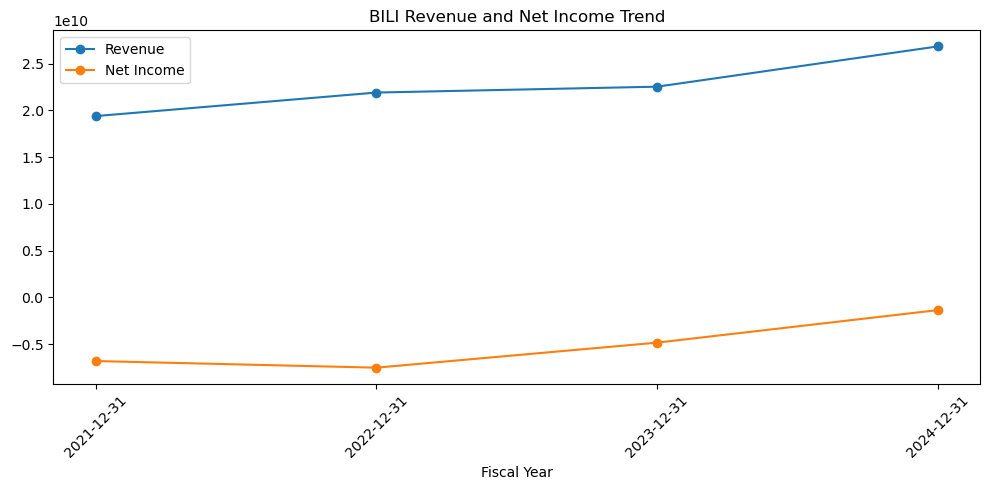

In [22]:
# Chart 1: Revenue and Net Income
plt.figure(figsize=(10, 5))
plt.plot(plot_annual.index, plot_annual["Revenue"], marker="o", label="Revenue")
plt.plot(plot_annual.index, plot_annual["Net Income"], marker="o", label="Net Income")
plt.title(f"{ticker_symbol} Revenue and Net Income Trend")
plt.xlabel("Fiscal Year")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig(output_dir / f"{ticker_symbol}_revenue_net_income.png", dpi=300)
plt.show()

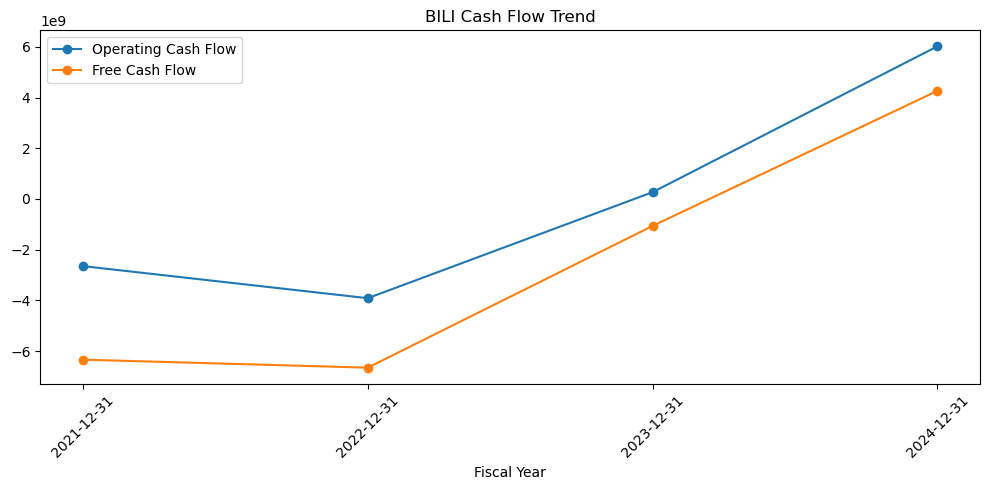

In [23]:
# Chart 2: Operating Cash Flow and Free Cash Flow
plt.figure(figsize=(10, 5))
plt.plot(plot_annual.index, plot_annual["Operating Cash Flow"], marker="o", label="Operating Cash Flow")
plt.plot(plot_annual.index, plot_annual["Free Cash Flow"], marker="o", label="Free Cash Flow")
plt.title(f"{ticker_symbol} Cash Flow Trend")
plt.xlabel("Fiscal Year")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig(output_dir / f"{ticker_symbol}_cash_flow_trend.png", dpi=300)
plt.show()

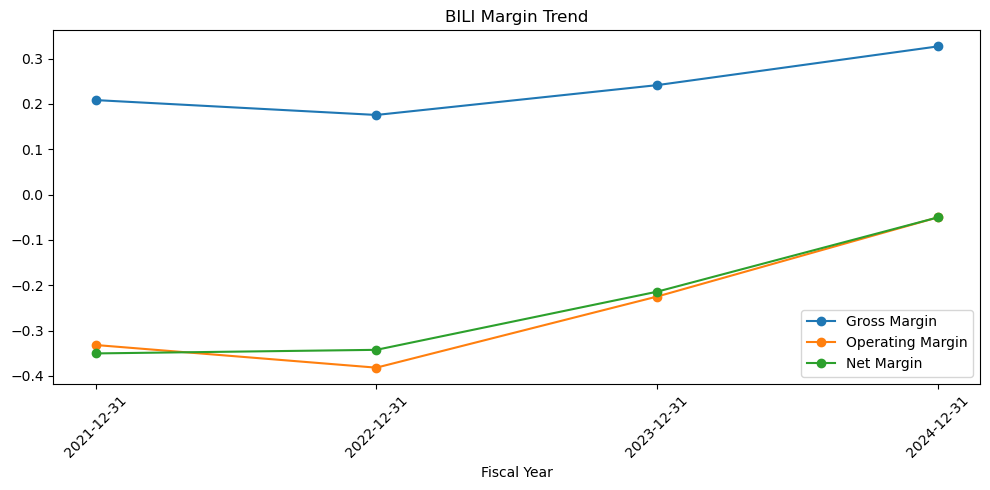

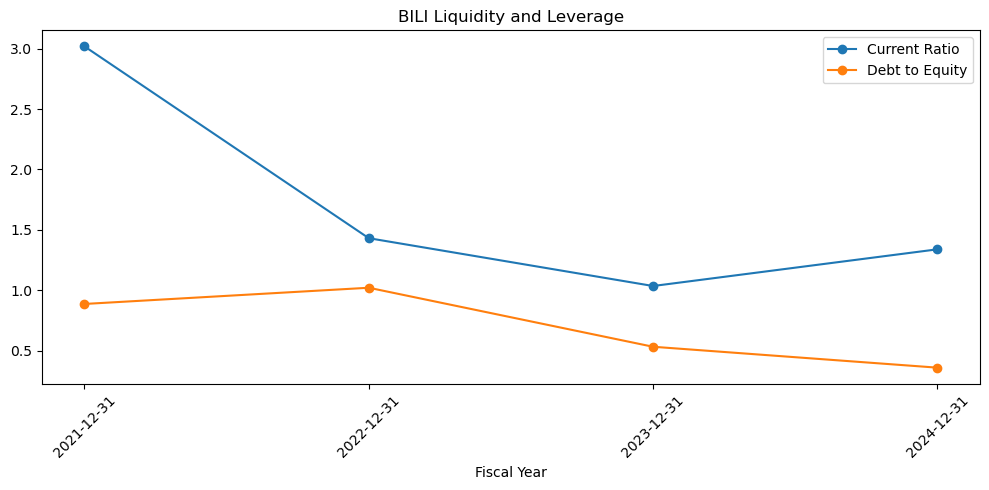

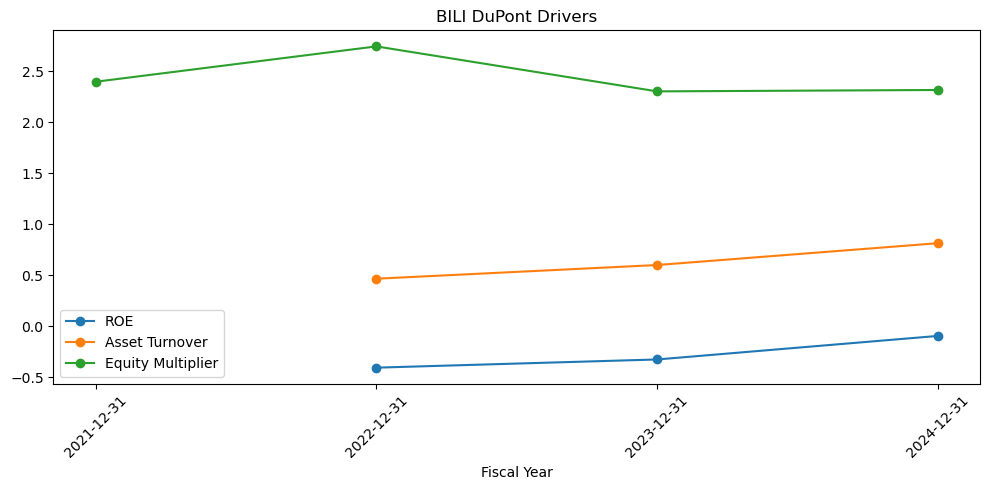

In [24]:
# Chart 3: Margin Trend
plt.figure(figsize=(10, 5))
plt.plot(plot_annual.index, plot_annual["Gross Margin"], marker="o", label="Gross Margin")
plt.plot(plot_annual.index, plot_annual["Operating Margin"], marker="o", label="Operating Margin")
plt.plot(plot_annual.index, plot_annual["Net Margin"], marker="o", label="Net Margin")
plt.title(f"{ticker_symbol} Margin Trend")
plt.xlabel("Fiscal Year")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig(output_dir / f"{ticker_symbol}_margin_trend.png", dpi=300)
plt.show()

# Chart 4: Liquidity and Leverage
plt.figure(figsize=(10, 5))
plt.plot(plot_annual.index, plot_annual["Current Ratio"], marker="o", label="Current Ratio")
plt.plot(plot_annual.index, plot_annual["Debt to Equity"], marker="o", label="Debt to Equity")
plt.title(f"{ticker_symbol} Liquidity and Leverage")
plt.xlabel("Fiscal Year")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig(output_dir / f"{ticker_symbol}_liquidity_leverage.png", dpi=300)
plt.show()

# Chart 5: DuPont-related Drivers
plt.figure(figsize=(10, 5))
plt.plot(plot_annual.index, plot_annual["ROE"], marker="o", label="ROE")
plt.plot(plot_annual.index, plot_annual["Asset Turnover"], marker="o", label="Asset Turnover")
plt.plot(plot_annual.index, plot_annual["Equity Multiplier"], marker="o", label="Equity Multiplier")
plt.title(f"{ticker_symbol} DuPont Drivers")
plt.xlabel("Fiscal Year")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig(output_dir / f"{ticker_symbol}_dupont_drivers.png", dpi=300)
plt.show()

## 16. Build a BILI-specific DuPont analysis chart and export outputs

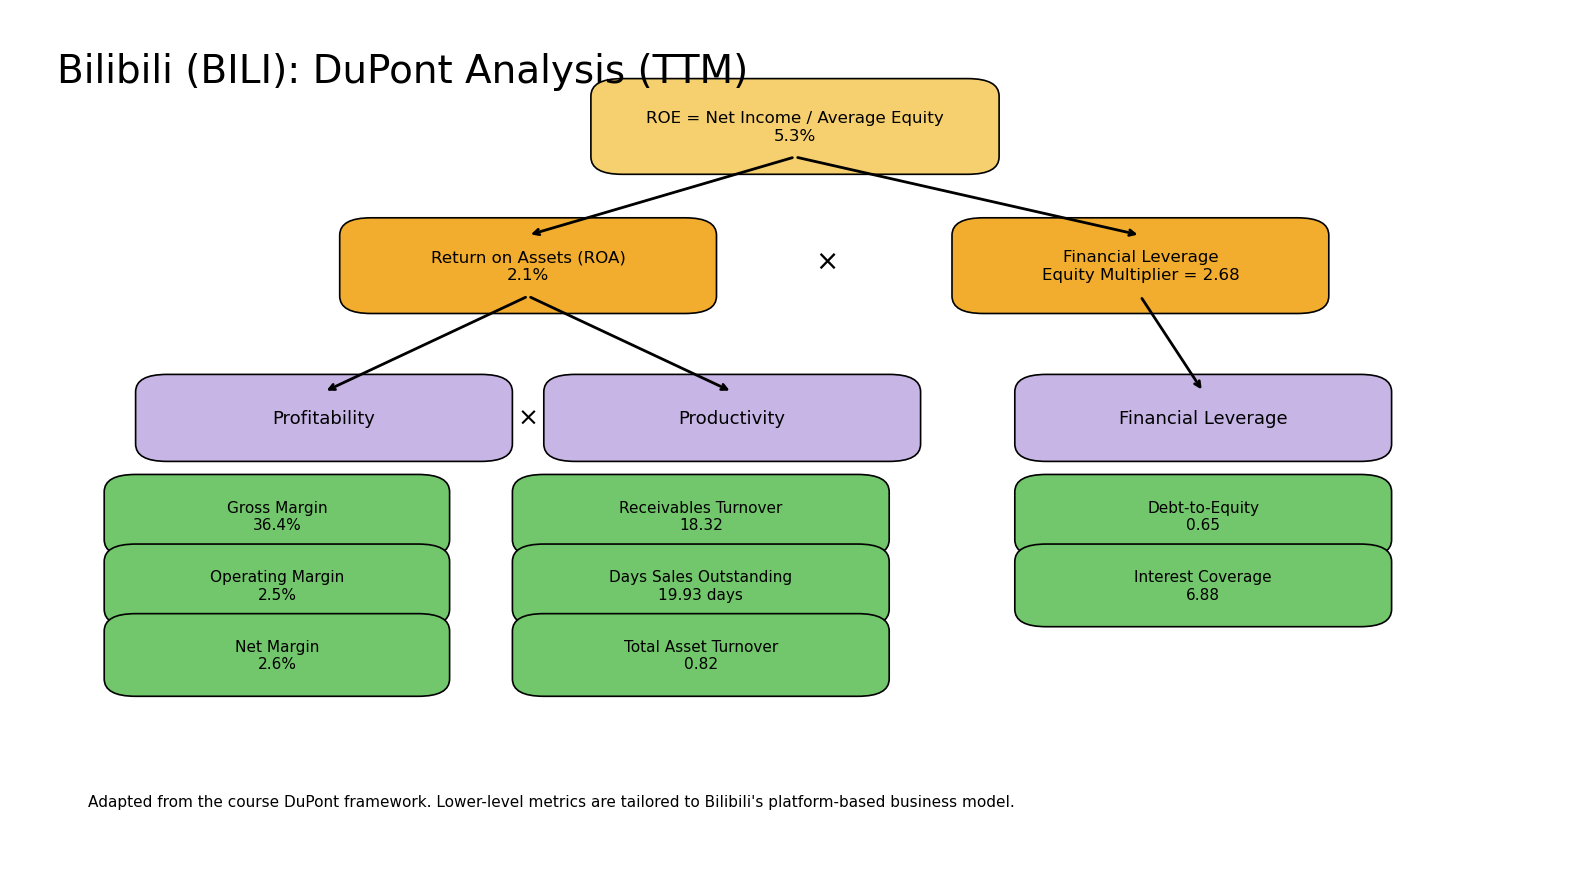

Saved Excel workbook to: /Users/fredericzhang/Documents/Study/ACCT/ACCT_626/bili_output/BILI_Financial_Analysis_Notebook_Output_Thousands.xlsx
All statement values and amount-based output tables are exported in thousands.
Charts saved to: /Users/fredericzhang/Documents/Study/ACCT/ACCT_626/bili_output


In [25]:
dupont_period = "TTM"
if dupont_period not in ratios.index:
    dupont_period = ratios.index[0]

dupont_values = {
    "ROE": ratios.loc[dupont_period, "ROE"],
    "ROA": ratios.loc[dupont_period, "ROA"],
    "Financial Leverage": ratios.loc[dupont_period, "Equity Multiplier"],
    "Gross Margin": ratios.loc[dupont_period, "Gross Margin"],
    "Operating Margin": ratios.loc[dupont_period, "Operating Margin"],
    "Net Margin": ratios.loc[dupont_period, "Net Margin"],
    "Receivables Turnover": ratios.loc[dupont_period, "Receivables Turnover"],
    "Days Sales Outstanding": ratios.loc[dupont_period, "Days Sales Outstanding"],
    "Total Asset Turnover": ratios.loc[dupont_period, "Total Asset Turnover"],
    "Debt to Equity": ratios.loc[dupont_period, "Debt to Equity"],
    "Interest Coverage": ratios.loc[dupont_period, "Interest Coverage"],
}

def fmt_pct(x):
    return "N/A" if pd.isna(x) else f"{x*100:.1f}%"

def fmt_num(x):
    return "N/A" if pd.isna(x) else f"{x:.2f}"

labels = {
    "ROE": f"ROE = Net Income / Average Equity\n{fmt_pct(dupont_values['ROE'])}",
    "ROA": f"Return on Assets (ROA)\n{fmt_pct(dupont_values['ROA'])}",
    "FL": f"Financial Leverage\nEquity Multiplier = {fmt_num(dupont_values['Financial Leverage'])}",
    "Profitability": "Profitability",
    "Productivity": "Productivity",
    "Leverage": "Financial Leverage",
    "GM": f"Gross Margin\n{fmt_pct(dupont_values['Gross Margin'])}",
    "OM": f"Operating Margin\n{fmt_pct(dupont_values['Operating Margin'])}",
    "NM": f"Net Margin\n{fmt_pct(dupont_values['Net Margin'])}",
    "RT": f"Receivables Turnover\n{fmt_num(dupont_values['Receivables Turnover'])}",
    "DSO": f"Days Sales Outstanding\n{fmt_num(dupont_values['Days Sales Outstanding'])} days",
    "TAT": f"Total Asset Turnover\n{fmt_num(dupont_values['Total Asset Turnover'])}",
    "DE": f"Debt-to-Equity\n{fmt_num(dupont_values['Debt to Equity'])}",
    "IC": f"Interest Coverage\n{fmt_num(dupont_values['Interest Coverage'])}",
}

def add_box(ax, x, y, w, h, text, fontsize=11, fc="#f3f3f3", ec="black", lw=1.2):
    box = FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.02,rounding_size=0.02",
        linewidth=lw, edgecolor=ec, facecolor=fc
    )
    ax.add_patch(box)
    ax.text(x + w/2, y + h/2, text, ha="center", va="center", fontsize=fontsize)
    return box

def arrow_down(ax, x1, y1, x2, y2):
    ax.annotate(
        "", xy=(x2, y2), xytext=(x1, y1),
        arrowprops=dict(arrowstyle="->", lw=2)
    )

fig, ax = plt.subplots(figsize=(16, 9))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

ax.text(
    0.03, 0.95,
    f"Bilibili (BILI): DuPont Analysis ({dupont_period})",
    fontsize=28, ha="left", va="top"
)

add_box(ax, 0.39, 0.83, 0.22, 0.07, labels["ROE"], fontsize=12, fc="#f6d06f")
add_box(ax, 0.23, 0.67, 0.20, 0.07, labels["ROA"], fontsize=12, fc="#f2ad2e")
add_box(ax, 0.62, 0.67, 0.20, 0.07, labels["FL"], fontsize=12, fc="#f2ad2e")

arrow_down(ax, 0.50, 0.83, 0.33, 0.74)
arrow_down(ax, 0.50, 0.83, 0.72, 0.74)
ax.text(0.52, 0.71, "×", fontsize=20, ha="center", va="center")

add_box(ax, 0.10, 0.50, 0.20, 0.06, labels["Profitability"], fontsize=13, fc="#c7b5e6")
add_box(ax, 0.36, 0.50, 0.20, 0.06, labels["Productivity"], fontsize=13, fc="#c7b5e6")
add_box(ax, 0.66, 0.50, 0.20, 0.06, labels["Leverage"], fontsize=13, fc="#c7b5e6")

arrow_down(ax, 0.33, 0.67, 0.20, 0.56)
arrow_down(ax, 0.33, 0.67, 0.46, 0.56)
ax.text(0.33, 0.53, "×", fontsize=18, ha="center", va="center")
arrow_down(ax, 0.72, 0.67, 0.76, 0.56)

add_box(ax, 0.08, 0.39, 0.18, 0.055, labels["GM"], fontsize=11, fc="#72c66b")
add_box(ax, 0.08, 0.31, 0.18, 0.055, labels["OM"], fontsize=11, fc="#72c66b")
add_box(ax, 0.08, 0.23, 0.18, 0.055, labels["NM"], fontsize=11, fc="#72c66b")

add_box(ax, 0.34, 0.39, 0.20, 0.055, labels["RT"], fontsize=11, fc="#72c66b")
add_box(ax, 0.34, 0.31, 0.20, 0.055, labels["DSO"], fontsize=11, fc="#72c66b")
add_box(ax, 0.34, 0.23, 0.20, 0.055, labels["TAT"], fontsize=11, fc="#72c66b")

add_box(ax, 0.66, 0.39, 0.20, 0.055, labels["DE"], fontsize=11, fc="#72c66b")
add_box(ax, 0.66, 0.31, 0.20, 0.055, labels["IC"], fontsize=11, fc="#72c66b")

ax.text(
    0.05, 0.08,
    "Adapted from the course DuPont framework. Lower-level metrics are tailored to Bilibili's platform-based business model.",
    fontsize=11, ha="left", va="bottom"
)

plt.tight_layout()
plt.savefig(output_dir / f"{ticker_symbol}_dupont_framework_{dupont_period}.png", dpi=300, bbox_inches="tight")
plt.show()

# Export workbook
inc_combined_export = scale_df(inc_combined, 1000)
bal_combined_export = scale_df(bal_combined, 1000)
cf_combined_export = scale_df(cf_combined, 1000)
summary_export = scale_df(summary, 1000)

excel_filename = output_dir / f"{ticker_symbol}_Financial_Analysis_Notebook_Output_Thousands.xlsx"

with pd.ExcelWriter(excel_filename, engine="openpyxl") as writer:
    inc_combined_export.to_excel(writer, sheet_name="Income_Statement")
    bal_combined_export.to_excel(writer, sheet_name="Balance_Sheet")
    cf_combined_export.to_excel(writer, sheet_name="Cash_Flow")
    summary_export.to_excel(writer, sheet_name="Summary")
    structure.to_excel(writer, sheet_name="Statement_Structure")
    avg_table.to_excel(writer, sheet_name="Average_Balances")
    ratios.to_excel(writer, sheet_name="Ratios_Raw")
    ratio_table.to_excel(writer, sheet_name="Ratios_Percent")
    report_ratios.to_excel(writer, sheet_name="Report_Ratios")
    report_table_display.to_excel(writer, sheet_name="Report_Table")

print(f"Saved Excel workbook to: {excel_filename.resolve()}")
print("All statement values and amount-based output tables are exported in thousands.")
print(f"Charts saved to: {output_dir.resolve()}")